In [2]:
# Step 1: Data Preparation & Cleaning
# Author: Bholu (Marketing Analytics Project)

import pandas as pd
import numpy as np

# 1. Load the raw dataset
df = pd.read_csv("C:/Users/Bholu Singh/Downloads/marketing_campaign_data.csv")

# 2. Quick sanity check
print("Initial shape:", df.shape)
print("Missing values:\n", df.isnull().sum())

# 3. Handle missing values
# Income is critical, so fill missing with median (robust to outliers)
df["Income"] = df["Income"].fillna(df["Income"].median())

# 4. Convert enrollment date to datetime
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], errors="coerce")

# 5. Derive Age from Year_Birth
current_year = 2026
df["Age"] = current_year - df["Year_Birth"]

# Remove unrealistic ages (<18 or >100)
df = df[(df["Age"] >= 18) & (df["Age"] <= 100)]

# 6. Feature Engineering
# Children count
df["Children"] = df["Kidhome"] + df["Teenhome"]

# Total spend across all product categories
spend_cols = ["MntWines","MntFruits","MntMeatProducts",
              "MntFishProducts","MntSweetProducts","MntGoldProds"]
df["Total_Spend"] = df[spend_cols].sum(axis=1)

# Total purchases across channels
purchase_cols = ["NumDealsPurchases","NumWebPurchases",
                 "NumCatalogPurchases","NumStorePurchases"]
df["Total_Purchases"] = df[purchase_cols].sum(axis=1)

# Customer tenure (days since enrollment)
df["Customer_Tenure"] = (pd.to_datetime("2026-03-24") - df["Dt_Customer"]).dt.days

# 7. Flags for segmentation
# High spender = above 90th percentile of spend
threshold = df["Total_Spend"].quantile(0.9)
df["High_Spender"] = np.where(df["Total_Spend"] > threshold, 1, 0)

# High web engagement = more than 5 visits per month
df["High_Web_Engagement"] = np.where(df["NumWebVisitsMonth"] > 5, 1, 0)

# 8. Save cleaned dataset
df.to_csv("cleaned_marketing_data.csv", index=False)

print("Data cleaning complete. Cleaned file saved as cleaned_marketing_data.csv")


Initial shape: (56000, 28)
Missing values:
 ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Response               0
Complain               0
Country                0
dtype: int64
Data cleaning complete. Cleaned file saved as cleaned_marketing_data.csv


Dataset shape: (56000, 35)
Columns: ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain', 'Country', 'Age', 'Children', 'Total_Spend', 'Total_Purchases', 'Customer_Tenure', 'High_Spender', 'High_Web_Engagement']
         ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0    342199        1985  Graduation       Together  59011.7        1   
1   8075450        1975      Master         Single   1730.0        1   
2  13664263        1978  Graduation        Married  98584.6        0   

   Teenhome Dt_Customer  Recency  MntWines  ...  Response  Complain  \
0         0  2012-11-17        3         0  ...         0      

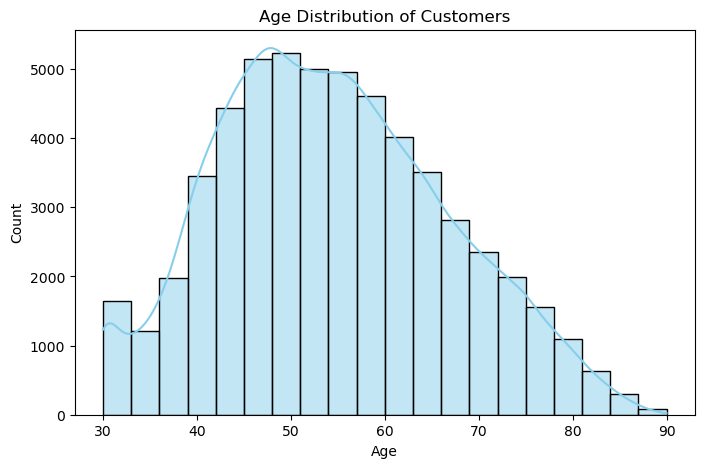

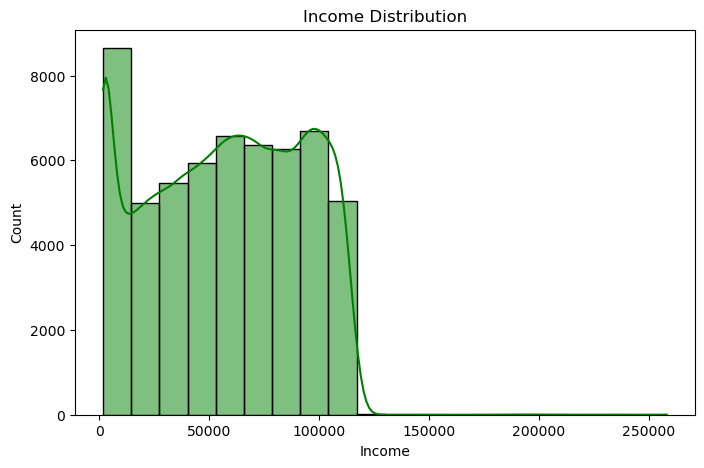

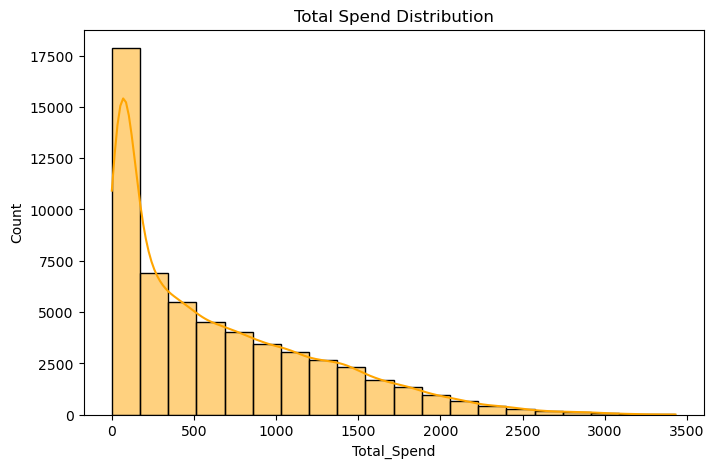

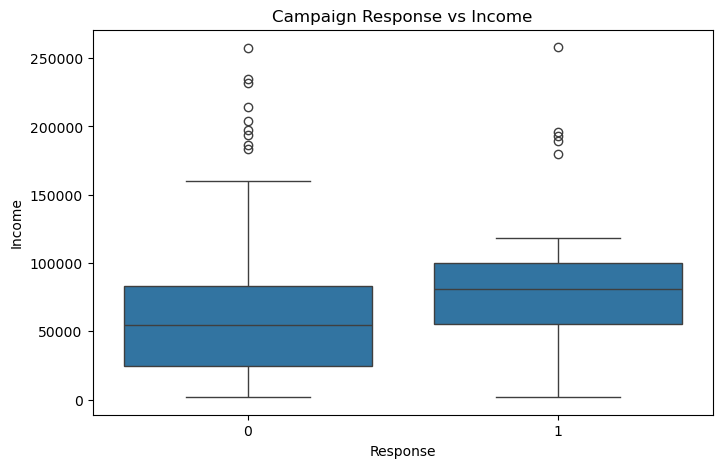

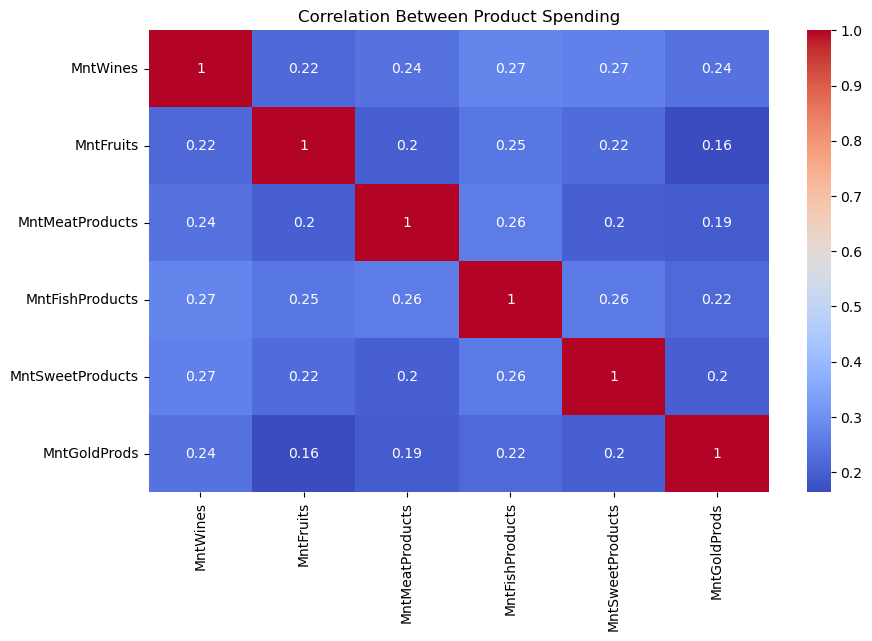


Average channel usage by campaign response:
           NumWebPurchases  NumCatalogPurchases  NumStorePurchases  \
Response                                                            
0                4.114214             1.983702           4.553137   
1                5.026739             2.844525           5.591652   

          NumDealsPurchases  
Response                     
0                  2.184100  
1                  2.101875  


In [5]:
# Step 2: Exploratory Data Analysis (EDA)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("cleaned_marketing_data.csv")

# Quick overview
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))

# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True, color="skyblue")
plt.title("Age Distribution of Customers")
plt.show()

# Income distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Income"], bins=20, kde=True, color="green")
plt.title("Income Distribution")
plt.show()

# Total spend distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Total_Spend"], bins=20, kde=True, color="orange")
plt.title("Total Spend Distribution")
plt.show()

# Response vs Income
plt.figure(figsize=(8,5))
sns.boxplot(x="Response", y="Income", data=df)
plt.title("Campaign Response vs Income")
plt.show()

# Correlation heatmap for product spending
spend_cols = ["MntWines","MntFruits","MntMeatProducts",
              "MntFishProducts","MntSweetProducts","MntGoldProds"]

plt.figure(figsize=(10,6))
sns.heatmap(df[spend_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Product Spending")
plt.show()

# Channel usage vs Response
channel_cols = ["NumWebPurchases","NumCatalogPurchases","NumStorePurchases","NumDealsPurchases"]
channel_response = df.groupby("Response")[channel_cols].mean()
print("\nAverage channel usage by campaign response:\n", channel_response)


In [6]:
# Step 3: Customer Segmentation

# High Income
df["High_Income"] = (df["Income"] > 75000).astype(int)

# Young Customer
df["Young_Customer"] = (df["Age"] < 30).astype(int)

# Campaign Responder
df["Campaign_Responder"] = (df["Response"] == 1).astype(int)

# High Web Engagement
df["High_Web_Engagement"] = (df["NumWebVisitsMonth"] > 5).astype(int)

# Family Customer
df["Family_Customer"] = (df["Children"] > 0).astype(int)

# High Spender (90th percentile)
threshold = df["Total_Spend"].quantile(0.9)
df["High_Spender"] = (df["Total_Spend"] > threshold).astype(int)

# Segment counts
segment_counts = {
    "High Income": df["High_Income"].sum(),
    "Young Customer": df["Young_Customer"].sum(),
    "Campaign Responder": df["Campaign_Responder"].sum(),
    "High Web Engagement": df["High_Web_Engagement"].sum(),
    "Family Customer": df["Family_Customer"].sum(),
    "High Spender": df["High_Spender"].sum()
}
print("Segmentation complete. Segment counts:\n", segment_counts)

# Save segmented dataset
df.to_csv("segmented_marketing_data.csv", index=False)


Segmentation complete. Segment counts:
 {'High Income': np.int64(19782), 'Young Customer': np.int64(0), 'Campaign Responder': np.int64(8265), 'High Web Engagement': np.int64(29970), 'Family Customer': np.int64(38222), 'High Spender': np.int64(5599)}


In [8]:
import pandas as pd
import mysql.connector

# Load segmented dataset
df = pd.read_csv("segmented_marketing_data.csv")

# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",        
    password="Bholu@0352", 
    database="marketing_campaign"
)
cursor = conn.cursor()

# Insert data row by row
for _, row in df.iterrows():
    sql = """
    INSERT INTO customers (
        ID, Year_Birth, Education, Marital_Status, Income, Kidhome, Teenhome,
        Dt_Customer, Recency, MntWines, MntFruits, MntMeatProducts, MntFishProducts,
        MntSweetProducts, MntGoldProds, NumDealsPurchases, NumWebPurchases,
        NumCatalogPurchases, NumStorePurchases, NumWebVisitsMonth,
        AcceptedCmp1, AcceptedCmp2, AcceptedCmp3, AcceptedCmp4, AcceptedCmp5,
        Response, Complain, Country, Age, Children, Total_Spend, Total_Purchases,
        Customer_Tenure, High_Spender, High_Web_Engagement, High_Income,
        Young_Customer, Campaign_Responder, Family_Customer
    ) VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,
              %s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
    """
    cursor.execute(sql, tuple(row))
conn.commit()
cursor.close()
conn.close()

print("Data successfully loaded into MySQL Workbench")


Data successfully loaded into MySQL Workbench
